In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

from scipy.signal.windows import tukey
from skimage.transform import radon
from scipy.fft import fft, ifft, fftfreq

from skimage.transform import iradon
import scipy.ndimage as ndimage

Génération des 9 ondes planes...


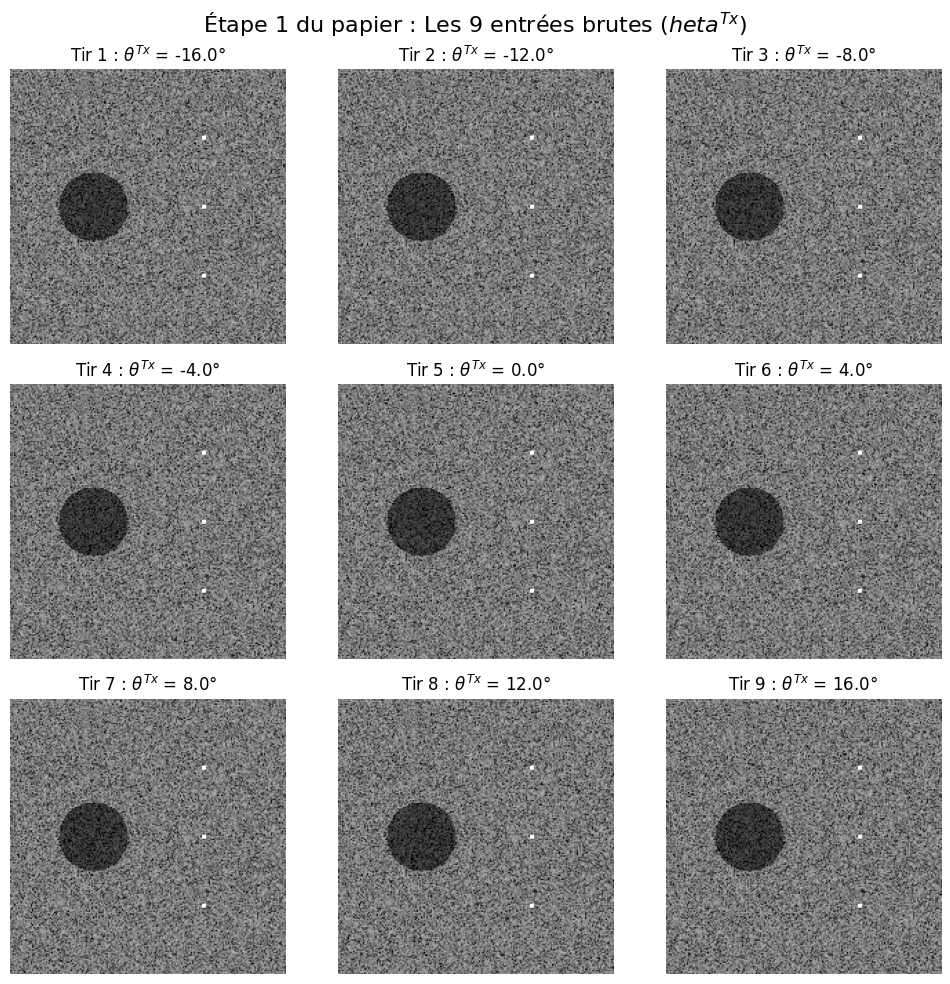

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# ==========================================
# ÉTAPE 1 : SIMULATION DES ACQUISITIONS (DELAY-AND-SUM)
# ==========================================
n_tx = 9  # 9 tirs d'ondes planes pour la grille 3x3
nz, nx = 200, 200
f0 = 0.12 
theta_tx = np.linspace(-16, 16, n_tx) # Balayage de -16° à +16°

np.random.seed(42)

# --- Création du fantôme tissulaire (La vérité terrain) ---
# a) Fond de speckle (tissu sain)
tissue = np.random.normal(0, 1.0, (nz, nx))
tissue = gaussian_filter(tissue, sigma=0.5)

# b) Kyste anéchogène (rond noir sans écho, centre gauche)
cz, cx, r = 100, 60, 25
Z_mesh, X_mesh = np.ogrid[:nz, :nx]
mask_cyst = (Z_mesh - cz)**2 + (X_mesh - cx)**2 <= r**2
tissue[mask_cyst] *= 0.05  

# c) Cibles ponctuelles (Points brillants à droite)
points_z = [50, 100, 150]
points_x = [140, 140, 140]
for pz, px in zip(points_z, points_x):
    tissue[pz-1:pz+2, px-1:px+2] = 15.0  

Z, X = np.indices((nz, nx))
carrier = np.exp(1j * 2 * np.pi * f0 * Z) # Onde porteuse ultrasonore

# --- Simulation de l'Aberration ---
# Écran de phase (simule une couche de graisse irrégulière sous la sonde)
phase_error = gaussian_filter(np.random.normal(0, 4.0, nx), sigma=6)

y_das_series = []
print("Génération des 9 ondes planes...")
for angle in theta_tx:
    # L'aberration "glisse" en fonction de l'angle d'émission (géométrie de l'onde plane)
    shift = int(30 * np.tan(np.deg2rad(angle)))
    local_phase = np.roll(phase_error, shift)
    aberration = np.exp(1j * 2 * np.pi * f0 * local_phase)
    
    # Création du signal complet avec ajout de bruit de mesure
    signal = tissue * aberration * carrier
    noise = np.random.normal(0, 0.05, (nz, nx)) + 1j * np.random.normal(0, 0.05, (nz, nx))
    
    # On stocke l'image reconstruite par Delay-and-Sum pour CE tir spécifique
    y_das_series.append(signal + noise)
    
y_das_series = np.array(y_das_series)

# ==========================================
# AFFICHAGE : GRILLE DES 9 ENTRÉES
# ==========================================
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Étape 1 du papier : Les 9 entrées brutes ($\theta^{Tx}$)", fontsize=16)

# On calcule le B-mode (dB) pour chaque tir
for i in range(n_tx):
    row, col = i // 3, i % 3
    ax = axes[row, col]
    
    # Enveloppe et log-compression (B-mode standard en échographie)
    b_mode = 20 * np.log10(np.abs(y_das_series[i]) + 1e-12)
    b_mode -= np.max(b_mode) # Calibration à 0 dB max pour un affichage homogène
    
    ax.imshow(b_mode, cmap='gray', vmin=-60, vmax=0)
    ax.set_title(f"Tir {i+1} : $\\theta^{{Tx}}$ = {theta_tx[i]:.1f}°")
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Laisse un peu de place pour le titre global
plt.show()


--- EXÉCUTION CELLULE 2 : RADON SUR UN PATCH ---
Affichage de la Figure 2. Fermez la fenêtre pour terminer le script.


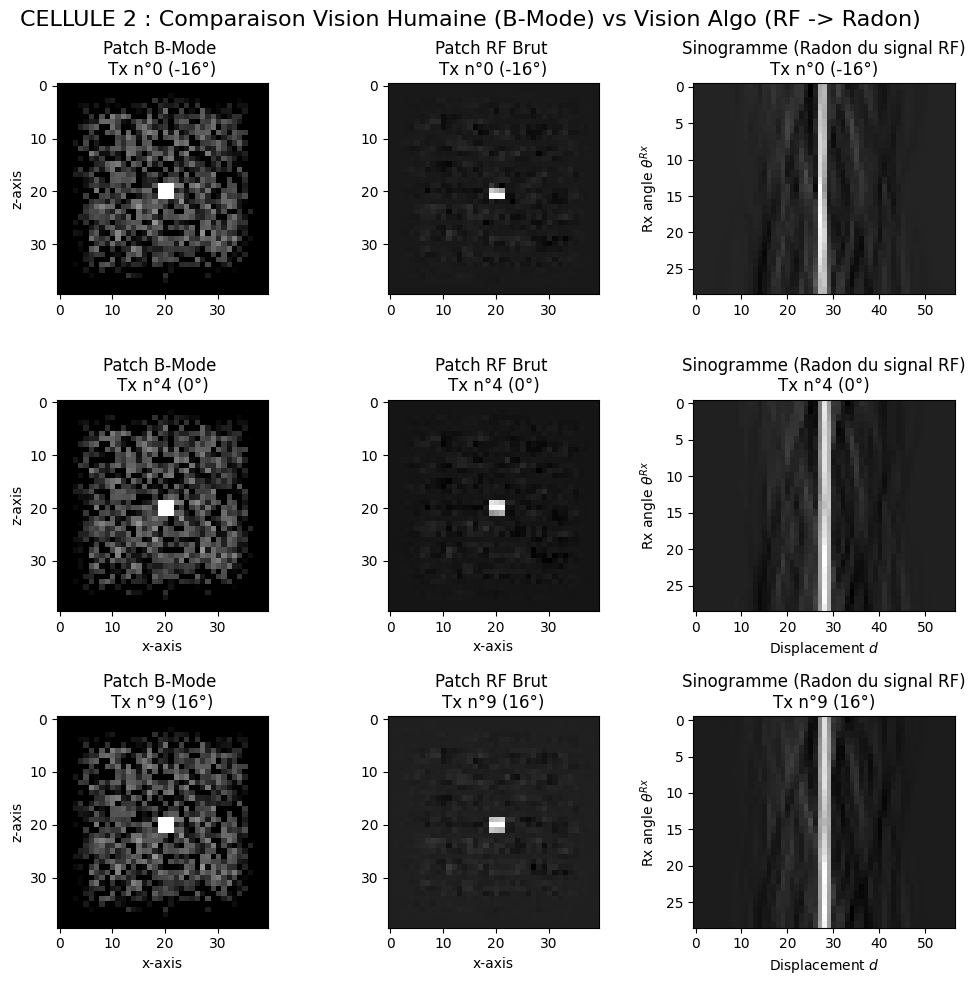

In [3]:
# =====================================================================
# CELLULE 2 : COMPARAISON B-MODE / RF ET TRANSFORMÉE DE RADON
# =====================================================================
print("\n--- EXÉCUTION CELLULE 2 : RADON SUR UN PATCH ---")

# 1. Paramètres du récepteur et de la fenêtre
theta_rx = np.arange(-35, 35.1, 2.5)
angles_skimage = theta_rx + 90 
n_rx = len(theta_rx)


win_size = 40
w_1d = tukey(win_size, alpha=0.5)
w_2d = np.outer(w_1d, w_1d)

# 2. Extraction du patch sur le point cible en haut à droite
z_patch, x_patch = 30, 120 
patches = y_das_series[:, z_patch:z_patch+win_size, x_patch:x_patch+win_size] * w_2d

# --- Traitement pour le Tir 0 (-16°) ---
# B-Mode (Enveloppe Logarithmique)
bmode_tx0 = 20 * np.log10(np.abs(patches[0]) + 1e-12)
bmode_tx0 -= np.max(bmode_tx0)
# Signal Brut RF (Vaguelettes)
patch_rf_tx0 = np.real(patches[0])
# Transformée de Radon sur le signal RF !
radon_tx0 = radon(patch_rf_tx0, theta=angles_skimage, circle=False)

# --- Traitement pour le Tir 4 (0°) ---
bmode_tx4 = 20 * np.log10(np.abs(patches[4]) + 1e-12)
bmode_tx4 -= np.max(bmode_tx4)
patch_rf_tx4 = np.real(patches[4])
radon_tx4 = radon(patch_rf_tx4, theta=angles_skimage, circle=False)

# --- Traitement pour le Tir 9 (16°) ---
bmode_tx9 = 20 * np.log10(np.abs(patches[8]) + 1e-12)
bmode_tx9 -= np.max(bmode_tx9)
patch_rf_tx9 = np.real(patches[8])
radon_tx9 = radon(patch_rf_tx9, theta=angles_skimage, circle=False)


# 4. Affichage Comparatif 
fig2, axes2 = plt.subplots(3, 3, figsize=(10, 10))
fig2.suptitle("CELLULE 2 : Comparaison Vision Humaine (B-Mode) vs Vision Algo (RF -> Radon)", fontsize=16)

# --- LIGNE 1 : TIR 0 ---
axes2[0, 0].imshow(bmode_tx0, cmap='gray', vmin=-40, vmax=0)
axes2[0, 0].set_title("Patch B-Mode \nTx n°0 (-16°)")
axes2[0, 0].set_ylabel("z-axis")

axes2[0, 1].imshow(patch_rf_tx0, cmap='gray')
axes2[0, 1].set_title("Patch RF Brut \nTx n°0 (-16°)")

im1 = axes2[0, 2].imshow(radon_tx0.T, cmap='gray', aspect='auto')
axes2[0, 2].set_title("Sinogramme (Radon du signal RF)\nTx n°0 (-16°)")
axes2[0, 2].set_ylabel("Rx angle $\\theta^{{Rx}}$")

# --- LIGNE 2 : TIR 4 ---
axes2[1, 0].imshow(bmode_tx4, cmap='gray', vmin=-40, vmax=0)
axes2[1, 0].set_title("Patch B-Mode \nTx n°4 (0°)")
axes2[1, 0].set_ylabel("z-axis")
axes2[1, 0].set_xlabel("x-axis")

axes2[1, 1].imshow(patch_rf_tx4, cmap='gray')
axes2[1, 1].set_title("Patch RF Brut \nTx n°4 (0°)")
axes2[1, 1].set_xlabel("x-axis")

im2 = axes2[1, 2].imshow(radon_tx4.T, cmap='gray', aspect='auto')
axes2[1, 2].set_title("Sinogramme (Radon du signal RF)\nTx n°4 (0°)")
axes2[1, 2].set_ylabel("Rx angle $\\theta^{{Rx}}$")
axes2[1, 2].set_xlabel("Displacement $d$")

# --- LIGNE 2 : TIR 9 ---
axes2[2, 0].imshow(bmode_tx9, cmap='gray', vmin=-40, vmax=0)
axes2[2, 0].set_title("Patch B-Mode \nTx n°9 (16°)")

axes2[2, 0].set_ylabel("z-axis")
axes2[2, 0].set_xlabel("x-axis")

axes2[2, 1].imshow(patch_rf_tx9, cmap='gray')
axes2[2, 1].set_title("Patch RF Brut \nTx n°9 (16°)")
axes2[2, 1].set_xlabel("x-axis")

im2 = axes2[2, 2].imshow(radon_tx9.T, cmap='gray', aspect='auto')
axes2[2, 2].set_title("Sinogramme (Radon du signal RF)\nTx n°9 (16°)")
axes2[2, 2].set_ylabel("Rx angle $\\theta^{{Rx}}$")
axes2[2, 2].set_xlabel("Displacement $d$")

plt.tight_layout()
print("Affichage de la Figure 2. Fermez la fenêtre pour terminer le script.")
plt.show()


--- EXÉCUTION CELLULE 3 : TENSOR RANK-1 DECOMPOSITION ---
Dimensions du Tenseur S : (9, 29, 57) (Tx, Rx, Déplacement d)
Lancement de l'algorithme ALS (8 itérations)...
Affichage de la Figure 3. Observez les vecteurs de phase extraits !


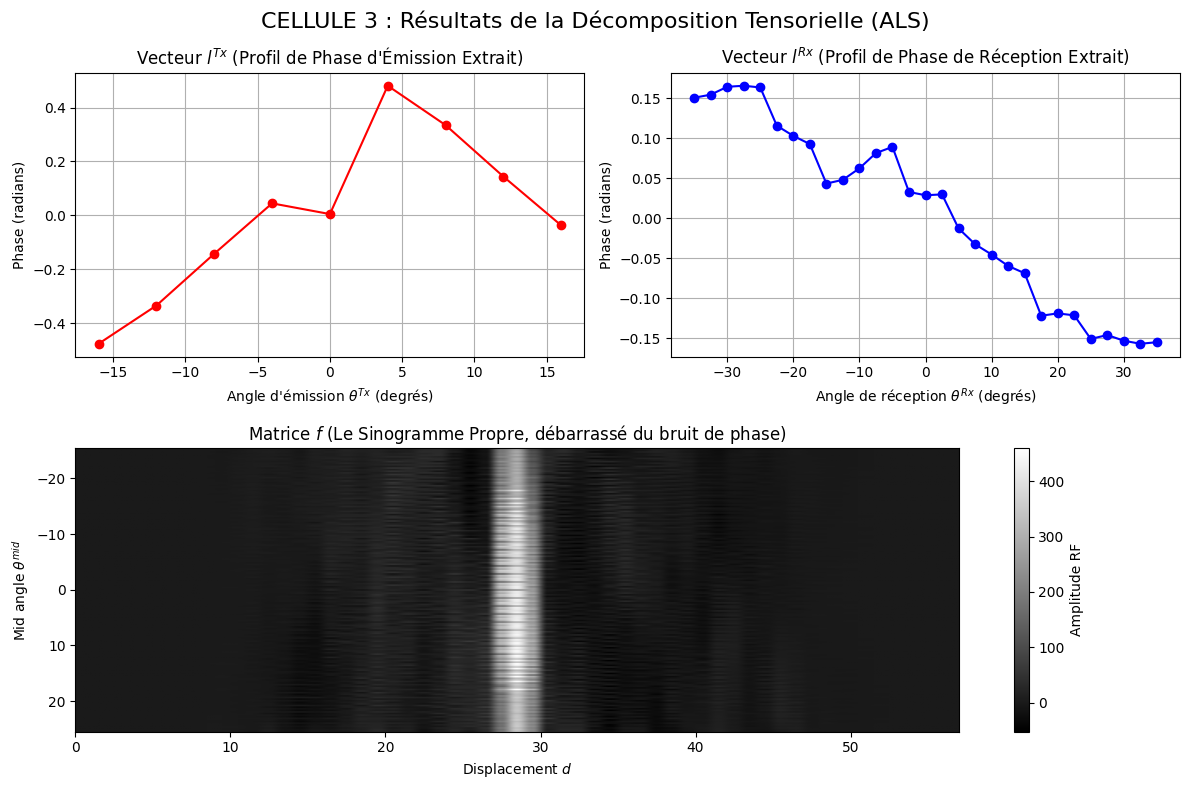

In [4]:
# =====================================================================
# CELLULE 3 : CRÉATION DU TENSEUR ET DÉCOMPOSITION RANK-1 (ALS)
# =====================================================================
print("\n--- EXÉCUTION CELLULE 3 : TENSOR RANK-1 DECOMPOSITION ---")

# 1. Empilement des 9 tirs pour former le Tenseur 3D "S"
s_patch = []
for i_tx in range(n_tx):
    patch = patches[i_tx]
    # On prend bien en compte la partie complexe complète !
    s_real = radon(np.real(patch), theta=angles_skimage, circle=False)
    s_imag = radon(np.imag(patch), theta=angles_skimage, circle=False)
    s_patch.append(s_real + 1j * s_imag)

# Transposition pour correspondre aux axes : (n_tx, n_rx, n_d)
s_patch = np.array(s_patch).transpose((0, 2, 1))
n_d = s_patch.shape[2]

print(f"Dimensions du Tenseur S : {s_patch.shape} (Tx, Rx, Déplacement d)")

# 2. Préparation des matrices géométriques pour l'ALS
theta_tx_grid, theta_rx_grid = np.meshgrid(theta_tx, theta_rx, indexing='ij')
theta_mid_matrix = (theta_tx_grid + theta_rx_grid) / 2
theta_mid_unique, mid_idx_matrix = np.unique(theta_mid_matrix, return_inverse=True)
mid_idx_matrix = mid_idx_matrix.reshape(n_tx, n_rx)
n_mid = len(theta_mid_unique)

# 3. Initialisation de l'algorithme ALS
mu = 0.005
l_tx = np.ones(n_tx, dtype=np.complex128)
l_rx = np.ones(n_rx, dtype=np.complex128)
f_mid = np.zeros((n_mid, n_d), dtype=np.complex128)

print("Lancement de l'algorithme ALS (8 itérations)...")
for iteration in range(8):
    norm_tx_sq, norm_rx_sq = np.sum(np.abs(l_tx)**2), np.sum(np.abs(l_rx)**2)
    
    # Mise à jour de f_mid (Le sinogramme propre)
    num_f = np.zeros((n_mid, n_d), dtype=np.complex128)
    den_f = np.zeros(n_mid, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            weight = np.conj(l_tx[i_tx]) * np.conj(l_rx[i_rx])
            num_f[m_idx, :] += weight * s_patch[i_tx, i_rx, :]
            den_f[m_idx] += np.abs(l_tx[i_tx] * l_rx[i_rx])**2
    f_mid = num_f / (den_f[:, None] + mu * norm_tx_sq * norm_rx_sq)
    norm_f_sq = np.sum(np.abs(f_mid)**2)
    
    # Mise à jour de l_rx (Vecteur de phase Rx)
    num_rx = np.zeros(n_rx, dtype=np.complex128)
    den_rx = np.zeros(n_rx, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            w_rx = np.conj(l_tx[i_tx]) * np.conj(f_mid[m_idx, :])
            num_rx[i_rx] += np.sum(w_rx * s_patch[i_tx, i_rx, :])
            den_rx[i_rx] += np.abs(l_tx[i_tx])**2 * np.sum(np.abs(f_mid[m_idx, :])**2)
    l_rx = num_rx / (den_rx + mu * norm_tx_sq * norm_f_sq)
    norm_rx_sq = np.sum(np.abs(l_rx)**2)
    
    # Mise à jour de l_tx (Vecteur de phase Tx - L'aberration principale !)
    num_tx = np.zeros(n_tx, dtype=np.complex128)
    den_tx = np.zeros(n_tx, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m_idx = mid_idx_matrix[i_tx, i_rx]
            w_tx = np.conj(l_rx[i_rx]) * np.conj(f_mid[m_idx, :])
            num_tx[i_tx] += np.sum(w_tx * s_patch[i_tx, i_rx, :])
            den_tx[i_tx] += np.abs(l_rx[i_rx])**2 * np.sum(np.abs(f_mid[m_idx, :])**2)
    l_tx = num_tx / (den_tx + mu * norm_rx_sq * norm_f_sq)

    # Normalisation pour éviter l'explosion des valeurs
    n_tx_norm = np.sqrt(np.sum(np.abs(l_tx)**2))
    n_rx_norm = np.sqrt(np.sum(np.abs(l_rx)**2))
    l_tx /= n_tx_norm
    l_rx /= n_rx_norm
    f_mid *= (n_tx_norm * n_rx_norm)

# 4. Affichage des résultats (Étape 3 du papier)
fig3 = plt.figure(figsize=(12, 8))
fig3.suptitle("CELLULE 3 : Résultats de la Décomposition Tensorielle (ALS)", fontsize=16)

# Affichage du profil de phase l_tx extrait (L'aberration devinée par l'algo)
ax1 = plt.subplot(2, 2, 1)
ax1.plot(theta_tx, np.angle(l_tx), marker='o', color='red', linestyle='-')
ax1.set_title("Vecteur $l^{Tx}$ (Profil de Phase d'Émission Extrait)")
ax1.set_xlabel("Angle d'émission $\\theta^{Tx}$ (degrés)")
ax1.set_ylabel("Phase (radians)")
ax1.grid(True)

# Affichage du profil de phase l_rx extrait
ax2 = plt.subplot(2, 2, 2)
ax2.plot(theta_rx, np.angle(l_rx), marker='o', color='blue', linestyle='-')
ax2.set_title("Vecteur $l^{Rx}$ (Profil de Phase de Réception Extrait)")
ax2.set_xlabel("Angle de réception $\\theta^{Rx}$ (degrés)")
ax2.set_ylabel("Phase (radians)")
ax2.grid(True)

# Affichage du Sinogramme cohérent f_mid extrait
ax3 = plt.subplot(2, 1, 2)
# On affiche f_mid (partie réelle) transposé pour avoir 'd' en X et 'theta' en Y
im3 = ax3.imshow(np.real(f_mid), cmap='gray', aspect='auto', 
                 extent=[0, n_d, theta_mid_unique[-1], theta_mid_unique[0]])
ax3.set_title("Matrice $f$ (Le Sinogramme Propre, débarrassé du bruit de phase)")
ax3.set_xlabel("Displacement $d$")
ax3.set_ylabel("Mid angle $\\theta^{mid}$")
plt.colorbar(im3, ax=ax3, label="Amplitude RF")

plt.tight_layout()
print("Affichage de la Figure 3. Observez les vecteurs de phase extraits !")
plt.show()

In [5]:
# =====================================================================
# CELLULE 4 : RECONSTRUCTION GLOBALE (FENÊTRE GLISSANTE)
# =====================================================================
print("\n--- EXÉCUTION CELLULE 4 : RECONSTRUCTION COMPLÈTE DE L'IMAGE ---")
step = 8 # Pas de la fenêtre glissante
output_image_f = np.zeros((nz, nx), dtype=np.complex128)
norm_map = np.zeros((nz, nx), dtype=np.float64)
patches_dict = {}

z_steps = list(range(0, nz - win_size + 1, step))
if z_steps[-1] + win_size < nz: z_steps.append(nz - win_size)
x_steps = list(range(0, nx - win_size + 1, step))
if x_steps[-1] + win_size < nx: x_steps.append(nx - win_size)

total_patches = len(z_steps) * len(x_steps)
print(f"Lancement du pipeline sur {total_patches} patchs. Veuillez patienter environ 30-60s...")

patch_count = 0
for z in z_steps:
    for x in x_steps:
        patch_series = y_das_series[:, z:z+win_size, x:x+win_size] * w_2d
        
        # 1. Transformée de Radon
        s_patch_local = []
        for i_tx in range(n_tx):
            patch = patch_series[i_tx]
            s_real = radon(np.real(patch), theta=angles_skimage, circle=False)
            s_imag = radon(np.imag(patch), theta=angles_skimage, circle=False)
            s_patch_local.append(s_real + 1j * s_imag) 
        s_patch_local = np.array(s_patch_local).transpose((0, 2, 1))
        
        # 2. Tensor Rank-1 ALS (Boucle optimisée à 5 itérations pour la vitesse)
        l_tx_local, l_rx_local = np.ones(n_tx, dtype=np.complex128), np.ones(n_rx, dtype=np.complex128)
        f_mid_local = np.zeros((n_mid, n_d), dtype=np.complex128)
        
        for _ in range(5):
            norm_tx_sq, norm_rx_sq = np.sum(np.abs(l_tx_local)**2), np.sum(np.abs(l_rx_local)**2)
            
            num_f = np.zeros((n_mid, n_d), dtype=np.complex128)
            den_f = np.zeros(n_mid, dtype=np.float64)
            for i_tx in range(n_tx):
                for i_rx in range(n_rx):
                    m_idx = mid_idx_matrix[i_tx, i_rx]
                    weight = np.conj(l_tx_local[i_tx]) * np.conj(l_rx_local[i_rx])
                    num_f[m_idx, :] += weight * s_patch_local[i_tx, i_rx, :]
                    den_f[m_idx] += np.abs(l_tx_local[i_tx] * l_rx_local[i_rx])**2
            f_mid_local = num_f / (den_f[:, None] + mu * norm_tx_sq * norm_rx_sq)
            norm_f_sq = np.sum(np.abs(f_mid_local)**2)
            
            num_rx = np.zeros(n_rx, dtype=np.complex128)
            den_rx = np.zeros(n_rx, dtype=np.float64)
            for i_tx in range(n_tx):
                for i_rx in range(n_rx):
                    m_idx = mid_idx_matrix[i_tx, i_rx]
                    w_rx = np.conj(l_tx_local[i_tx]) * np.conj(f_mid_local[m_idx, :])
                    num_rx[i_rx] += np.sum(w_rx * s_patch_local[i_tx, i_rx, :])
                    den_rx[i_rx] += np.abs(l_tx_local[i_tx])**2 * np.sum(np.abs(f_mid_local[m_idx, :])**2)
            l_rx_local = num_rx / (den_rx + mu * norm_tx_sq * norm_f_sq)
            norm_rx_sq = np.sum(np.abs(l_rx_local)**2)
            
            num_tx = np.zeros(n_tx, dtype=np.complex128)
            den_tx = np.zeros(n_tx, dtype=np.float64)
            for i_tx in range(n_tx):
                for i_rx in range(n_rx):
                    m_idx = mid_idx_matrix[i_tx, i_rx]
                    w_tx = np.conj(l_rx_local[i_rx]) * np.conj(f_mid_local[m_idx, :])
                    num_tx[i_tx] += np.sum(w_tx * s_patch_local[i_tx, i_rx, :])
                    den_tx[i_tx] += np.abs(l_rx_local[i_rx])**2 * np.sum(np.abs(f_mid_local[m_idx, :])**2)
            l_tx_local = num_tx / (den_tx + mu * norm_rx_sq * norm_f_sq)

            n_tx_norm = np.sqrt(np.sum(np.abs(l_tx_local)**2))
            n_rx_norm = np.sqrt(np.sum(np.abs(l_rx_local)**2))
            l_tx_local /= n_tx_norm
            l_rx_local /= n_rx_norm
            f_mid_local *= (n_tx_norm * n_rx_norm)

        # 3. Phase Correction Spatiale (Au lieu du iradon pour éviter les artefacts)
        y_f_w = np.zeros((win_size, win_size), dtype=np.complex128)
        for i_tx in range(n_tx):
            y_f_w += patch_series[i_tx] * np.conj(l_tx_local[i_tx])
        y_f_w *= (1.0 / np.sqrt(n_tx))
        
        patches_dict[(z, x)] = y_f_w
        norm_map[z:z+win_size, x:x+win_size] += (w_2d ** 2)
        
        patch_count += 1
        if patch_count % 50 == 0:
            print(f"Progression : {patch_count} / {total_patches} patchs traités...")

print("Alignement des phases des patchs (Overlap-Add)...")
output_image_f.fill(0)

# Passe d'Initialisation Séquentielle 
for (z, x), y_f_w in patches_dict.items():
    y_f_0 = output_image_f[z:z+win_size, x:x+win_size]
    v = np.sum(y_f_0 * np.conj(y_f_w))
    if np.abs(v) > 1e-10:
        y_f_w = (v / np.abs(v)) * y_f_w 
    patches_dict[(z, x)] = y_f_w
    output_image_f[z:z+win_size, x:x+win_size] += y_f_w

# Affinage global 
for i_out in range(3):
    for (z, x), y_f_w in patches_dict.items():
        y_f_0 = output_image_f[z:z+win_size, x:x+win_size] - y_f_w
        v = np.sum(y_f_0 * np.conj(y_f_w))
        if np.abs(v) > 1e-10:
            patches_dict[(z, x)] = (v / np.abs(v)) * y_f_w
            
    output_image_f.fill(0)
    for (z, x), y_f_w in patches_dict.items():
        output_image_f[z:z+win_size, x:x+win_size] += y_f_w

mask = norm_map > 1e-5
output_image_f[mask] /= norm_map[mask]


--- EXÉCUTION CELLULE 4 : RECONSTRUCTION COMPLÈTE DE L'IMAGE ---
Lancement du pipeline sur 441 patchs. Veuillez patienter environ 30-60s...
Progression : 50 / 441 patchs traités...
Progression : 100 / 441 patchs traités...
Progression : 150 / 441 patchs traités...
Progression : 200 / 441 patchs traités...
Progression : 250 / 441 patchs traités...
Progression : 300 / 441 patchs traités...
Progression : 350 / 441 patchs traités...
Progression : 400 / 441 patchs traités...
Alignement des phases des patchs (Overlap-Add)...


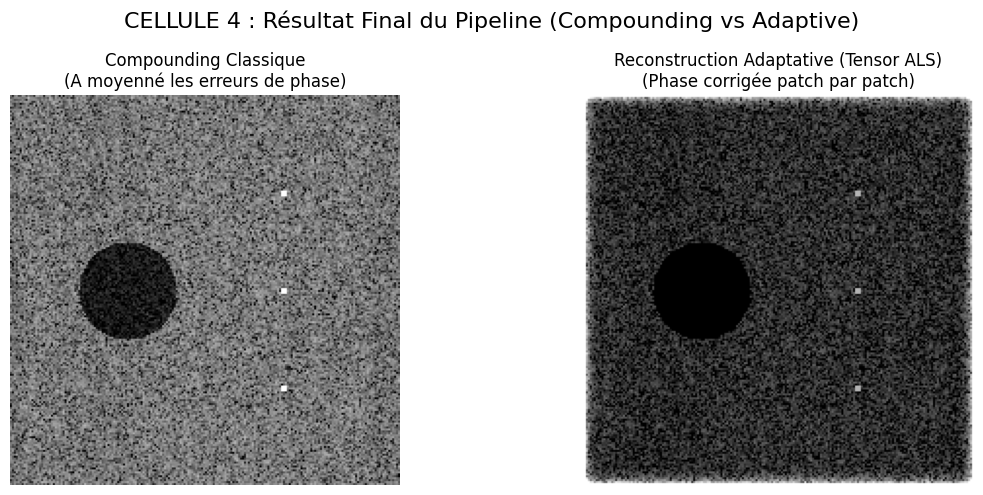

Pipeline terminé avec succès !


In [6]:

# =====================================================================
# AFFICHAGE FINAL COMPARATIF
# =====================================================================
base_compounding = np.mean(y_das_series, axis=0)
base_b_mode = 20 * np.log10(np.abs(base_compounding) + 1e-12)
base_b_mode -= np.max(base_b_mode)

b_mode = np.zeros((nz, nx))
b_mode_temp = 20 * np.log10(np.abs(output_image_f) + 1e-12)
b_mode[mask] = b_mode_temp[mask] - np.max(b_mode_temp[mask])

fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))
fig4.suptitle("CELLULE 4 : Résultat Final du Pipeline (Compounding vs Adaptive)", fontsize=16)

axes4[0].imshow(base_b_mode, cmap='gray', vmin=-60, vmax=0)
axes4[0].set_title("Compounding Classique\n(A moyenné les erreurs de phase)")

axes4[1].imshow(b_mode, cmap='gray', vmin=-60, vmax=0)
axes4[1].set_title("Reconstruction Adaptative (Tensor ALS)\n(Phase corrigée patch par patch)")
for ax in axes4: ax.axis('off')
plt.tight_layout()
plt.show()
print("Pipeline terminé avec succès !")